<a href="https://colab.research.google.com/github/jfilloon/fairness-in-machine-learning/blob/main/notebooks/fairness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Fairness in Machine Learning Models
Deep Learning Term Project
---

Examination of bias and fairness in machine learning models using Adult Income Dataset. A baseline classifier will be evaluated with performance and fairness metrics. It is followed bu a bias mitigation technique to compare changes in accuracy and fairness

In [89]:
!pip install fairlearn

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate
)

# **Load Dataset**

In [91]:
adult = fetch_openml(
    name="adult", version=2, as_frame=True
)
df = adult.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


The above code loads the Adult Income dataset into pandas dataframe. This contains demographic and employment information to predict annual income and whether it exceeds $50,000

Explore Dataset

In [92]:
print("Dataset shape:" , df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (48842, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [93]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [94]:
print(df["class"].value_counts())


print (df["class"].value_counts(normalize=True)* 100)

print(df["sex"].value_counts())

print(df["race"].value_counts())

class
<=50K    37155
>50K     11687
Name: count, dtype: int64
class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64
sex
Male      32650
Female    16192
Name: count, dtype: int64
race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64


In [95]:
pd.crosstab(
    df["sex"],
    df["class"],
    normalize="index",
)* 100

class,<=50K,>50K
sex,,
Female,89.074852,10.925148
Male,69.623277,30.376723


Above code looks at distribution of categorical variables to identify class imbalance, uncommon categories and preprocessing needs


## Data Visualization

Section uses vizualizations to examine distribution of target variables and sensitive attributes. Identifies class imbalance and group differences before training

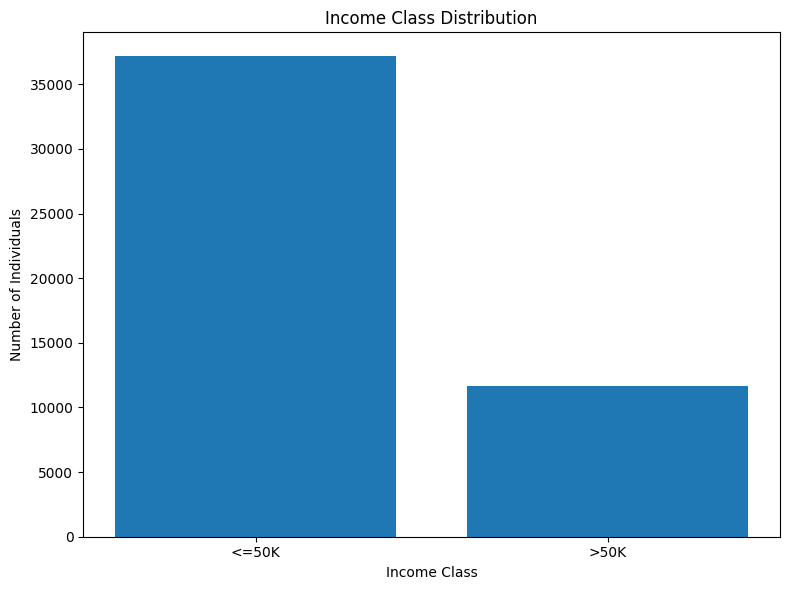

In [96]:
import matplotlib.pyplot as plt
income_counts = df["class"].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(income_counts.index, income_counts.values)
plt.xlabel("Income Class")
plt.ylabel("Number of Individuals")
plt.title("Income Class Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


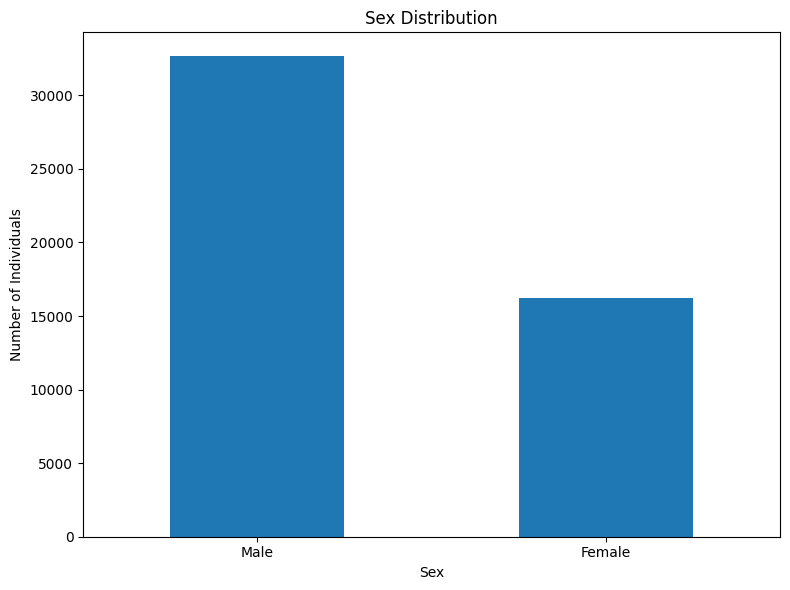

In [97]:
sex_counts = df["sex"].value_counts()

plt.figure(figsize=(8, 6))
sex_counts.plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Number of Individuals")
plt.title("Sex Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

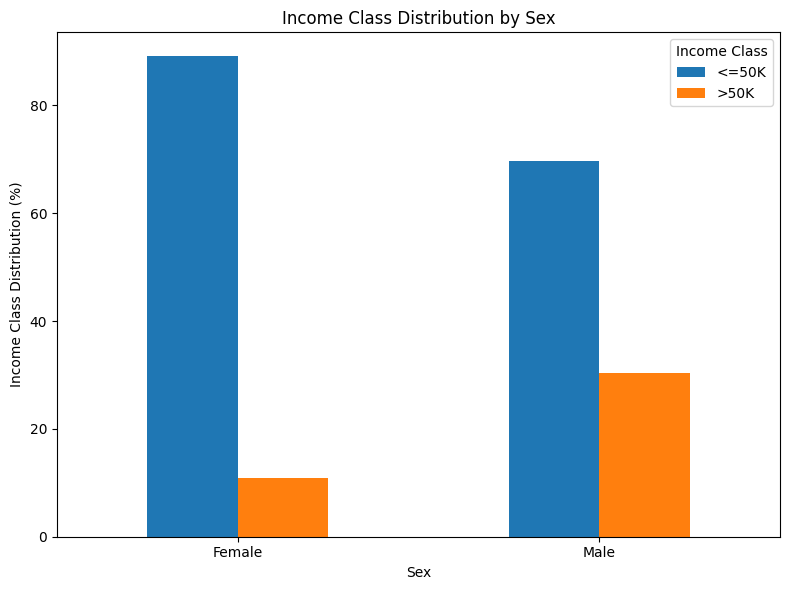

In [98]:
income_by_sex = pd.crosstab(
    df["sex"],
    df["class"],
    normalize="index",
) * 100

income_by_sex.plot(kind="bar", figsize=(8, 6))
plt.xlabel("Sex")
plt.ylabel("Income Class Distribution (%)")
plt.title("Income Class Distribution by Sex")
plt.xticks(rotation=0)
plt.legend(title="Income Class")
plt.tight_layout()
plt.show()


Percentage better for use as more males than females in data set
Shows percentage of females and males in each data class

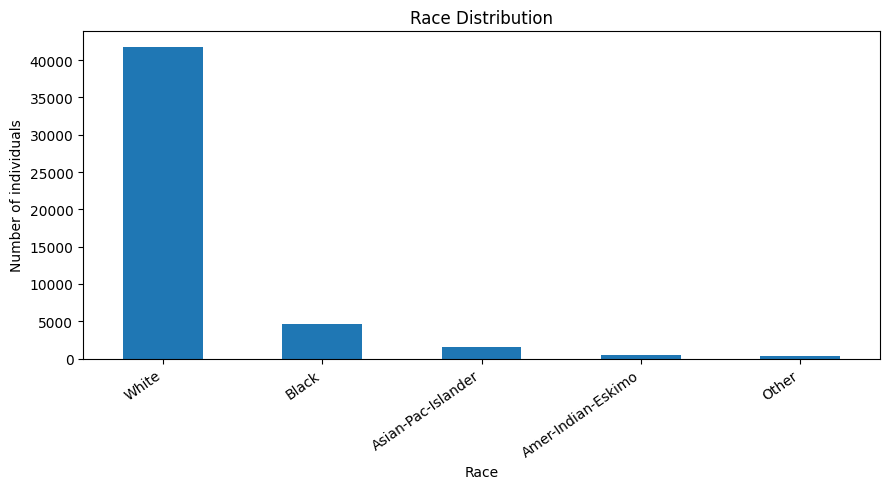

In [99]:
race_counts = df["race"].value_counts()
plt.figure(figsize=(9,5))
race_counts.plot(kind="bar")

plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Number of individuals")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

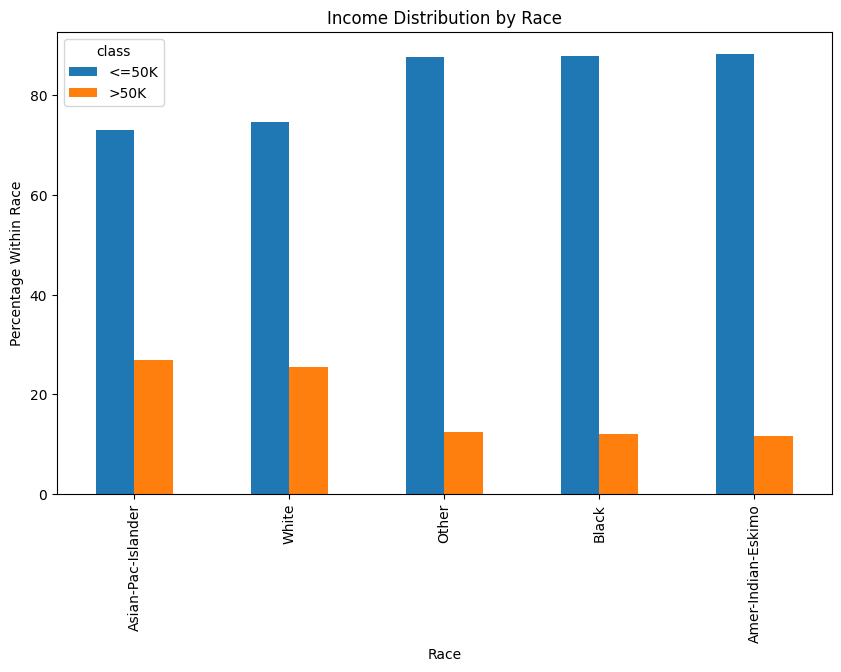

In [100]:
income_by_race = pd.crosstab(
    df["race"],
    df["class"],
    normalize="index"
) * 100

income_by_race = income_by_race.sort_values(
    by=">50K",
    ascending = False
)

income_by_race.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Income Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Percentage Within Race")
plt.show()

This visualization compares the percentage of individuals earning more than and less than \$50,000 within each racial group. Examining the relationship between race and income before training the model provides context for later fairness analyses and helps identify potential disparities that may already exist in the data.

## Data Preprocessing

In [101]:
y = df["class"].map({
    "<=50K": 0,
    ">50K": 1
})
x = df.drop(columns=["class"])
print("Features shape:", x.shape)
print("Target shape:", y.shape)


Features shape: (48842, 14)
Target shape: (48842,)


In [102]:
sensitive_feature = x["sex"]
sensitive_feature.value_counts()

,count
sex,
Male,32650
Female,16192


The protected attribute used for the initial fairness analysis is sex. This variable will not be predicted by the model but will instead be used to evaluate whether model performance differs across demographic groups.

In [103]:
x.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


###Numerical and Categorical Features

In [104]:
numerical_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = x.select_dtypes(include=["category", "object"]).columns.tolist()

print("Numerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)

Numerical Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


###Feature Prep

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features),
        ("numerical",
        "passthrough",
         numerical_features)])

print(preprocessor)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country']),
                                ('numerical', 'passthrough',
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week'])])


In [106]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    x,
    y,
    sensitive_feature,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", x_train.shape)
print("Testing set:", x_test.shape)

Training set: (39073, 14)
Testing set: (9769, 14)


In [107]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [108]:
baseline_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country']),
                                                 ('numerical', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [109]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = baseline_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8466577950660252
Precision: 0.7315325248070562
Recall: 0.567579127459367
F1 Score: 0.6392100192678227


###FAIRNESS EVAL

In [119]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

# y_test is already numerical (0, 1) due to mapping in cell DM-oG4GLIuFi
y_test_numeric = y_test
# y_pred is a numpy array of 0s and 1s, convert to Series for consistency
y_pred_numeric = pd.Series(y_pred)

baseline_fairness = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

print("Metrics by group:")
print(baseline_fairness.by_group)

print("\nDemographic parity difference:")
print(
    demographic_parity_difference(
        y_true=y_test_numeric,
        y_pred=y_pred_numeric,
        sensitive_features=sensitive_test
    )
)

print("\nEqualized odds difference:")
print(equalized_odds_difference(
        y_true=y_test_numeric,
        y_pred=y_pred_numeric,
        sensitive_features=sensitive_test
    )
)

Metrics by group:
        accuracy  selection_rate
sex                             
Female  0.925130        0.070881
Male    0.807373        0.243164

Demographic parity difference:
0.17228372428661454

Equalized odds difference:
0.10121241927596719


In [120]:
###Fairness Mitigation
from fairlearn.postprocessing import ThresholdOptimizer

In [121]:
mitigator = ThresholdOptimizer(
    estimator=baseline_model,
    constraints="demographic_parity",
    prefit=True
)

In [122]:
mitigator.fit(
    x_train,
    y_train,
    sensitive_features=sensitive_train
)

ThresholdOptimizer(estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['workclass',
                                                                                'education',
                                                                                'marital-status',
                                                                                'occupation',
                                                                                'relationship',
                                                                                'race',
                                                                                'sex',
                                                                                'native-country']),
                                                                              ('numerical',
                                                                               'passthrough',
                                                                               ['age',
                                                                                'fnlwgt',
                                                                                'education-num',
                                                                                'capital-gain',
                                                                                'capital-loss',
                                                                                'hours-per-week'])])),
                                             ('classifier',
                                              LogisticRegression(max_iter=1000))]),
                   prefit=True)

In [123]:
y_pred_mitigated = mitigator.predict(
    x_test,
    sensitive_features=sensitive_test,
    random_state=42
)

In [124]:
accuracy_mitigated = accuracy_score(y_test, y_pred_mitigated)
precision_mitigated = precision_score(y_test, y_pred_mitigated)
recall_mitigated = recall_score(y_test, y_pred_mitigated)
f1_mitigated = f1_score(y_test, y_pred_mitigated)

print("Accuracy:", accuracy_mitigated)
print("Precision:", precision_mitigated)
print("Recall:", recall_mitigated)
print("F1 Score:", f1_mitigated)

Accuracy: 0.8218855563517249
Precision: 0.6838868388683886
Recall: 0.4756201881950385
F1 Score: 0.5610494450050454


In [125]:
mitigated_fairness = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=y_pred_mitigated,
    sensitive_features=sensitive_test
)

mitigated_dp = demographic_parity_difference(
    y_test,
    y_pred_mitigated,
    sensitive_features=sensitive_test
)

mitigated_eo = equalized_odds_difference(
    y_test,
    y_pred_mitigated,
    sensitive_features=sensitive_test
)

print("Metrics by group:")
print(mitigated_fairness.by_group)

print("\nDemographic parity difference:")
print(mitigated_dp)

print("\nEqualized odds difference:")
print(mitigated_eo)

Metrics by group:
        accuracy  selection_rate
sex                             
Female  0.873888        0.169377
Male    0.795853        0.164977

Demographic parity difference:
0.004400151017458914

Equalized odds difference:
0.2597825127470061


In [126]:
baseline_dp = demographic_parity_difference(
    y_true=y_test,
    y_pred=pd.Series(y_pred),
    sensitive_features=sensitive_test
)

baseline_eo = equalized_odds_difference(
    y_true=y_test,
    y_pred=pd.Series(y_pred),
    sensitive_features=sensitive_test
)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Demographic Parity Difference",
        "Equalized Odds Difference"
    ],
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1,
        baseline_dp,
        baseline_eo
    ],
    "Mitigated": [
        accuracy_mitigated,
        precision_mitigated,
        recall_mitigated,
        f1_mitigated,
        mitigated_dp,
        mitigated_eo
    ]
})

comparison

,Metric,Baseline,Mitigated
0,Accuracy,0.846658,0.821886
1,Precision,0.731533,0.683887
2,Recall,0.567579,0.475620
3,F1 Score,0.639210,0.561049
4,Demographic Parity Difference,0.172284,0.004400
5,Equalized Odds Difference,0.101212,0.259783
